# Model Evaluation & Error Analysis

This stage evaluates the final tuned Random Forest model on unseen test data and examines how closely the predictions follow actual energy consumption patterns.

In [14]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
final_model = joblib.load('../models/final_random_forest.pkl')
test = pd.read_csv('../data/test.csv', parse_dates=['date'])
x_test = test[['date','hour','minute','month','Day_of_week','WeekStatus','lag_1','lag_2','lag_4',
                 'lag_96','lag_672']]
y_test = test['Usage_kWh']
predictions = final_model.predict(x_test)

## Actual vs Predicted Energy Usage

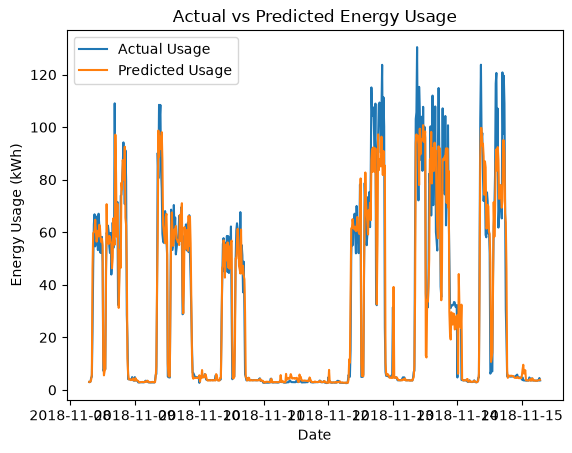

In [9]:
test_plot = test.copy()
test_plot['Predicted_Usage'] = predictions
start_date = test_plot['date'].min()
end_date = start_date + pd.Timedelta(days = 7)

plot_data = test_plot[(test_plot['date'] >= start_date) & (test_plot['date'] < end_date)]

fig, ax = plt.subplots()
sns.lineplot(data = plot_data, x = 'date', y = 'Usage_kWh', label = 'Actual Usage', ax = ax)
sns.lineplot(data = plot_data, x = 'date', y = 'Predicted_Usage', label = 'Predicted Usage', ax = ax)
ax.set_title('Actual vs Predicted Energy Usage')
ax.set_xlabel('Date')
ax.set_ylabel('Energy Usage (kWh)')
ax.legend()

Findings: The actual and predicted energy consumption followed very similar patterns throughout the seven-day test period, indicating that the model was able to capture the general temporal pattern of energy usage. The predictions closely tracked the repeated rises and falls in consumption, including periods of low activity and high operational demand. However, the model tended to smooth some of the sharper peaks, with actual usage occasionally rising above the predicted values during periods of high consumption. This suggests that while the model captures the overall operating pattern well, it has some difficulty responding to sudden increases in energy demand.

## Prediction Accuracy Across Energy Usage Levels

Text(0, 0.5, 'Predicted Usage')

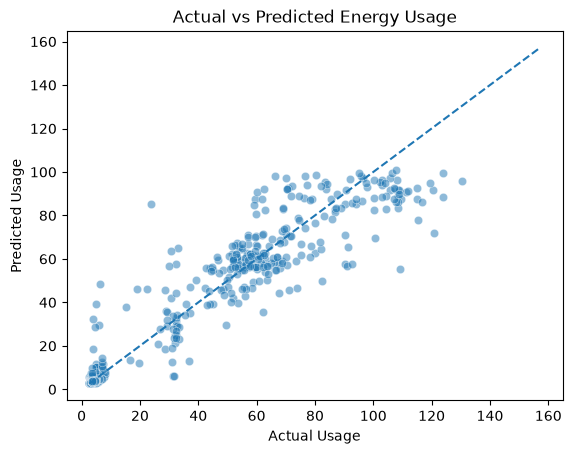

In [13]:
fig, ax = plt.subplots()
sns.scatterplot(data = plot_data, x = 'Usage_kWh', y = 'Predicted_Usage', ax = ax, alpha = 0.5)
min_value = min(test_plot['Usage_kWh'].min(), test_plot['Predicted_Usage'].min())
max_value = max(test_plot['Usage_kWh'].max(), test_plot['Predicted_Usage'].max())
ax.plot([min_value, max_value], [min_value, max_value], linestyle = '--', label = 'Perfect Prediction')
ax.set_title('Actual vs Predicted Energy Usage')
ax.set_xlabel('Actual Usage')
ax.set_ylabel('Predicted Usage')

Findings: Predictions generally track actual consumption, particularly across the mid-range, but errors become more noticeable toward the extremes. The model appears to have a tendency to smooth unusual consumption levels, particularly underpredicting some high-demand observations.

Conclusion: The model appears useful for understanding and forecasting general energy-consumption patterns. However, its suitability for precise operational decisions depends on the magnitude and distribution of its prediction errors, particularly during high-demand periods.